# Unemployment Analysis with Python

### CodeAlpha Data Science Internship — Task 2

## Project Overview

This project focuses on analyzing unemployment rate data in India to
understand unemployment trends over time and investigate the impact of
the COVID-19 pandemic.

Python is used for data cleaning, exploratory data analysis,
visualization, and interpretation of unemployment trends.

The project also investigates regional differences, seasonal patterns,
and the relationship between unemployment and labour participation.

## Objective

The main objectives of this project are:

1. Load and understand the unemployment dataset.
2. Clean and preprocess the data.
3. Perform exploratory data analysis.
4. Analyze unemployment trends over time.
5. Investigate the impact of COVID-19 on unemployment rates.
6. Compare unemployment rates across different regions.
7. Identify seasonal patterns in unemployment.
8. Analyze the relationship between unemployment and labour participation.
9. Create meaningful visualizations.
10. Generate insights that can support economic and social policies.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab
- GitHub

## Dataset

The dataset contains unemployment-related information for different
regions of India over time.

### Features

| Feature | Description |
|---|---|
| Region | Indian state or region |
| Date | Date of observation |
| Frequency | Frequency of data collection |
| Estimated Unemployment Rate (%) | Percentage of unemployed people |
| Estimated Employed | Estimated number of employed people |
| Estimated Labour Participation Rate (%) | Percentage of working-age population participating in the labour force |
| Area | Geographic classification such as Rural or Urban |

### Main Variable

The primary variable analyzed in this project is:

**Estimated Unemployment Rate (%)**

It represents the percentage of unemployed people in the given
region and time period.

# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Load the Dataset

The dataset is uploaded directly into Google Colab.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 21.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5


In [6]:
import os
csv_file_name = 'Unemployment_Rate_upto_11_2020.csv'
file_path = os.path.join(path, csv_file_name)

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("File:", csv_file_name)

Dataset loaded successfully!
File: Unemployment_Rate_upto_11_2020.csv


# 3. Understand the Dataset

In [7]:
# Display first five rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [8]:
# Display last five rows
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,31-10-2020,M,9.98,33962549,45.63,East,22.9868,87.855


In [9]:
# Number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 267
Columns: 9


In [10]:
# Display column names
print("Column Names:")
for column in df.columns:
    print(column)

Column Names:
Region
 Date
 Frequency
 Estimated Unemployment Rate (%)
 Estimated Employed
 Estimated Labour Participation Rate (%)
Region.1
longitude
latitude


In [11]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [12]:
# Statistical summary
df.describe(include="all")

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
count,267,267,267,267.000000,2.670000e+02,267.000000,267,267.000000,267.000000
unique,27,10,1,NaN,NaN,NaN,5,NaN,NaN
top,Andhra Pradesh,31-05-2020,M,NaN,NaN,NaN,North,NaN,NaN
freq,10,27,267,NaN,NaN,NaN,79,NaN,NaN
mean,NaN,NaN,NaN,12.236929,1.396211e+07,41.681573,NaN,22.826048,80.532425
std,NaN,NaN,NaN,10.803283,1.336632e+07,7.845419,NaN,6.270731,5.831738
min,NaN,NaN,NaN,0.500000,1.175420e+05,16.770000,NaN,10.850500,71.192400
25%,NaN,NaN,NaN,4.845000,2.838930e+06,37.265000,NaN,18.112400,76.085600
50%,NaN,NaN,NaN,9.650000,9.732417e+06,40.390000,NaN,23.610200,79.019300
75%,NaN,NaN,NaN,16.755000,2.187869e+07,44.055000,NaN,27.278400,85.279900


# 4. Data Cleaning and Preprocessing

Before performing the analysis, the dataset is checked for:

- Missing values
- Duplicate records
- Incorrect column names
- Incorrect data types
- Date formatting issues
- Unnecessary spaces

In [13]:
# Remove unnecessary spaces from column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [14]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [15]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [16]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (267, 9)


In [17]:
# Clean all string/object columns
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

print("String columns cleaned successfully.")

String columns cleaned successfully.


# 5. Convert Date Column

The Date column is converted into datetime format so that
time-series analysis can be performed.

In [18]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].head())
print("\nDate data type:", df["Date"].dtype)

0   2020-01-31
1   2020-02-29
2   2020-03-31
3   2020-04-30
4   2020-05-31
Name: Date, dtype: datetime64[ns]

Date data type: datetime64[ns]


/tmp/ipykernel_2197/3259999494.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


In [19]:
# Check invalid dates
print("Invalid dates:", df["Date"].isnull().sum())

Invalid dates: 0


# 6. Check the Cleaned Dataset

In [20]:
print("Dataset Shape:", df.shape)

display(df.head())

print("\nMissing Values:")
display(df.isnull().sum())

Dataset Shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74



Missing Values:


,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


# 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand:

- Distribution of unemployment rates
- Average unemployment rate
- Minimum and maximum unemployment rates
- Regional differences
- Changes over time

In [21]:
# Average unemployment rate
average_unemployment = df["Estimated Unemployment Rate (%)"].mean()

print(f"Average Unemployment Rate: {average_unemployment:.2f}%")

Average Unemployment Rate: 12.24%


In [22]:
# Minimum and maximum unemployment rate

min_rate = df["Estimated Unemployment Rate (%)"].min()
max_rate = df["Estimated Unemployment Rate (%)"].max()

print(f"Minimum Unemployment Rate: {min_rate:.2f}%")
print(f"Maximum Unemployment Rate: {max_rate:.2f}%")

Minimum Unemployment Rate: 0.50%
Maximum Unemployment Rate: 75.85%


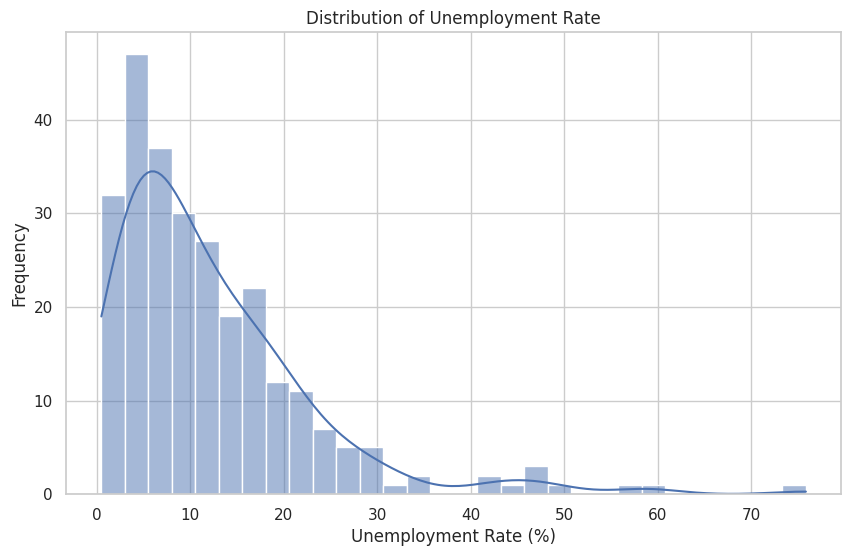

In [23]:
# Distribution of unemployment rate

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    bins=30,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

## Interpretation

The distribution shows how frequently different unemployment rate
values occur in the dataset. This helps identify the typical range
of unemployment rates and unusually high or low observations.

# 8. Unemployment Trend Over Time

This section analyzes how the unemployment rate changed over time.

In [24]:
# Calculate monthly average unemployment rate

monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

monthly_unemployment.head()

,Date,Estimated Unemployment Rate (%)
0,2020-01-31,9.196538
1,2020-02-29,9.266154
2,2020-03-31,10.782593
3,2020-04-30,22.236154
4,2020-05-31,23.244444


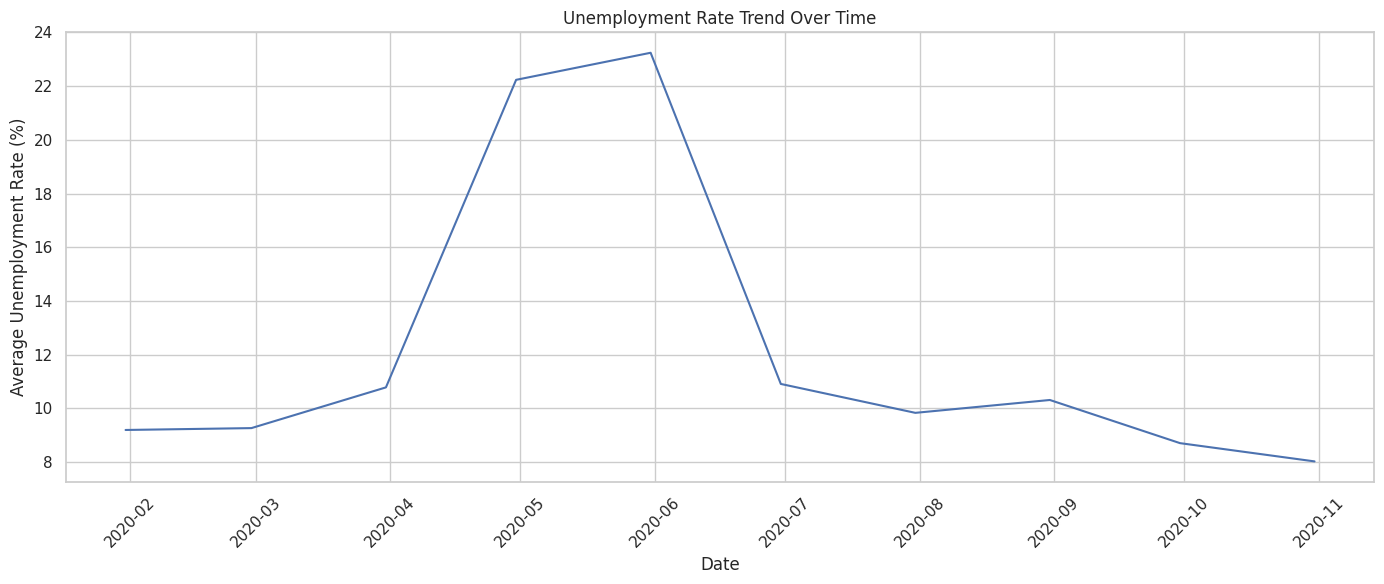

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment["Date"],
    monthly_unemployment["Estimated Unemployment Rate (%)"]
)

plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 9. COVID-19 Impact Analysis

The COVID-19 pandemic had a significant impact on employment and
economic activity.

For this analysis, unemployment rates are compared across different
periods:

- Pre-COVID: Before March 2020
- COVID Period: March 2020 onwards
- Post-COVID: If sufficient later data is available

The purpose is to determine how unemployment changed during the
pandemic.

In [27]:
# Create COVID period classification

def classify_period(date):
    if date < pd.Timestamp("2020-03-01"):
        return "Pre-COVID"
    elif date <= pd.Timestamp("2021-12-31"):
        return "COVID Period"
    else:
        return "Post-COVID"

df["COVID Period"] = df["Date"].apply(classify_period)

df[["Date", "COVID Period"]].head()

,Date,COVID Period
0,2020-01-31,Pre-COVID
1,2020-02-29,Pre-COVID
2,2020-03-31,COVID Period
3,2020-04-30,COVID Period
4,2020-05-31,COVID Period


In [28]:
# Average unemployment rate by COVID period

covid_analysis = (
    df.groupby("COVID Period")["Estimated Unemployment Rate (%)"]
    .agg(["mean", "min", "max"])
    .round(2)
)

covid_analysis

,mean,min,max
COVID Period,,,
COVID Period,12.96,0.50,75.85
Pre-COVID,9.23,0.58,32.67


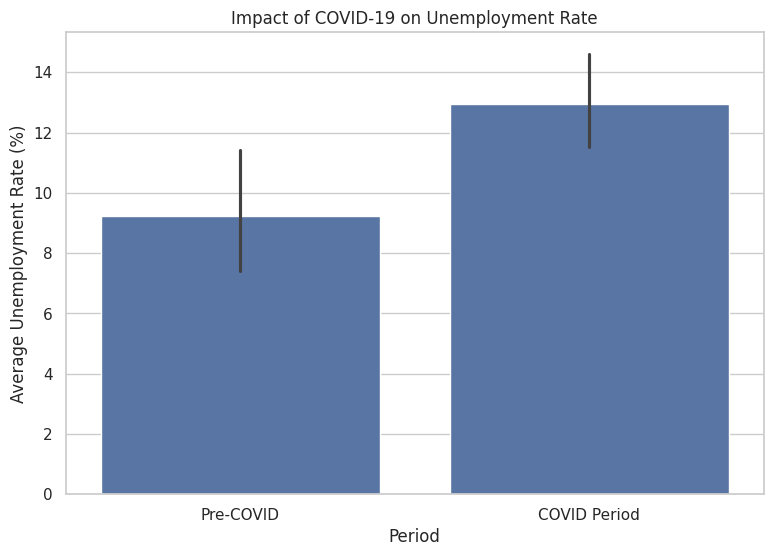

In [29]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="COVID Period",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Impact of COVID-19 on Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

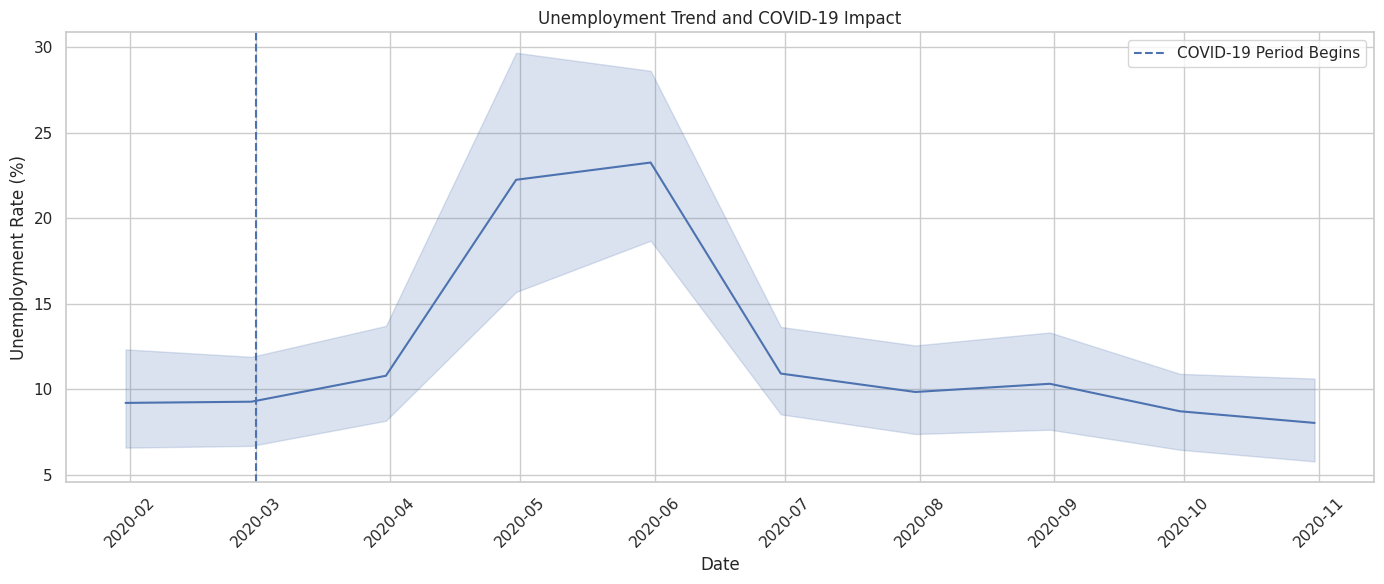

In [30]:
# COVID period trend

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Unemployment Rate (%)"
)

plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--",
    label="COVID-19 Period Begins"
)

plt.title("Unemployment Trend and COVID-19 Impact")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 10. Regional Unemployment Analysis

This section compares unemployment rates across different regions
of India.

The objective is to identify regions with relatively higher and
lower unemployment rates.

In [31]:
regional_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

regional_unemployment

,Estimated Unemployment Rate (%)
Region,
Haryana,27.477000
Tripura,25.055000
Jharkhand,19.539000
Bihar,19.471000
Delhi,18.414000
Puducherry,17.942000
Jammu & Kashmir,16.477778
Himachal Pradesh,16.065000
Rajasthan,15.868000


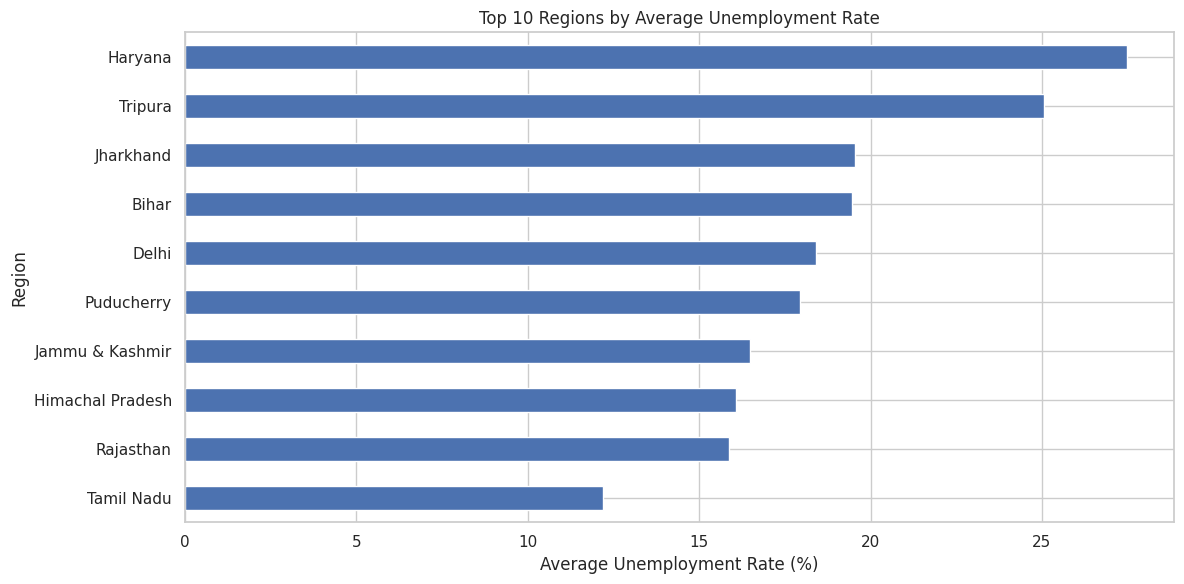

In [32]:
# Top 10 regions with highest unemployment

top_regions = regional_unemployment.head(10)

plt.figure(figsize=(12, 6))

top_regions.sort_values().plot(kind="barh")

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

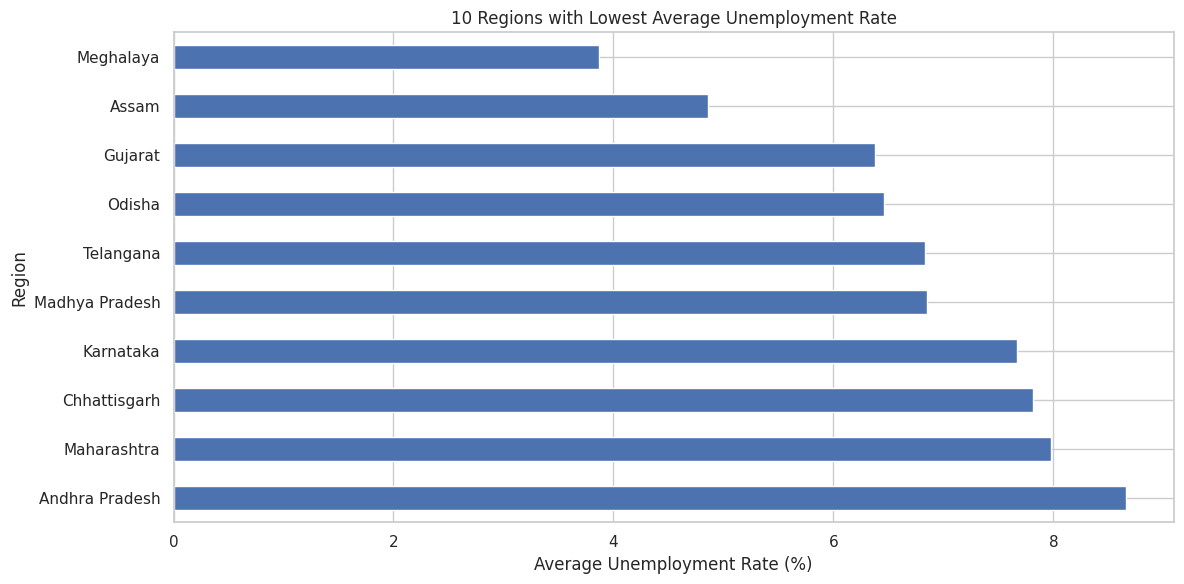

In [33]:
# Top 10 regions with lowest unemployment

lowest_regions = regional_unemployment.tail(10)

plt.figure(figsize=(12, 6))

lowest_regions.sort_values(ascending=False).plot(kind="barh")

plt.title("10 Regions with Lowest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

# 11. Rural vs Urban Analysis

If the dataset contains an Area column, unemployment rates can be
compared between Rural and Urban areas.

In [35]:
area_analysis = (
    df.groupby("Region.1")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

area_analysis

,Estimated Unemployment Rate (%)
Region.1,
North,15.889620
East,13.916000
Northeast,10.950263
South,10.454667
West,8.239000


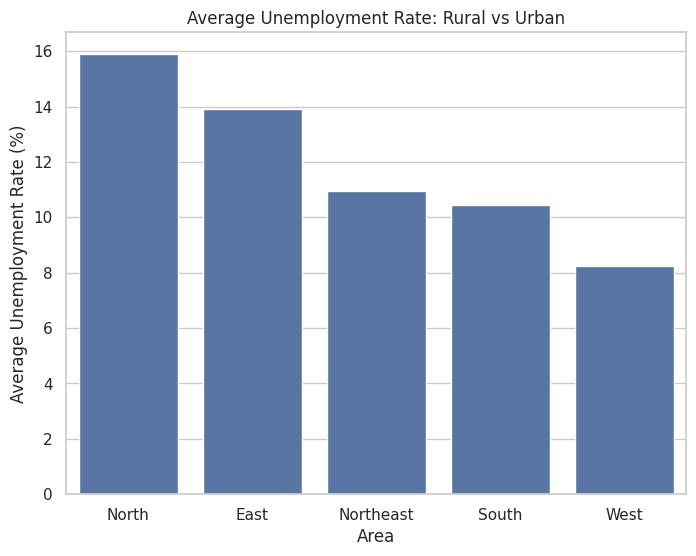

In [36]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=area_analysis.index,
    y=area_analysis.values
)

plt.title("Average Unemployment Rate: Rural vs Urban")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

# 12. Seasonal Trend Analysis

Unemployment may vary across different months of the year.

To investigate possible seasonal patterns, the month is extracted
from the Date column and average unemployment is calculated for
each month.

In [37]:
df["Month"] = df["Date"].dt.month
df["Month Name"] = df["Date"].dt.month_name()

monthly_pattern = (
    df.groupby(["Month", "Month Name"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
    .sort_values("Month")
)

monthly_pattern

,Month,Month Name,Estimated Unemployment Rate (%)
0,1,January,9.196538
1,2,February,9.266154
2,3,March,10.782593
3,4,April,22.236154
4,5,May,23.244444
5,6,June,10.911111
6,7,July,9.834444
7,8,August,10.313333
8,9,September,8.705926
9,10,October,8.026296


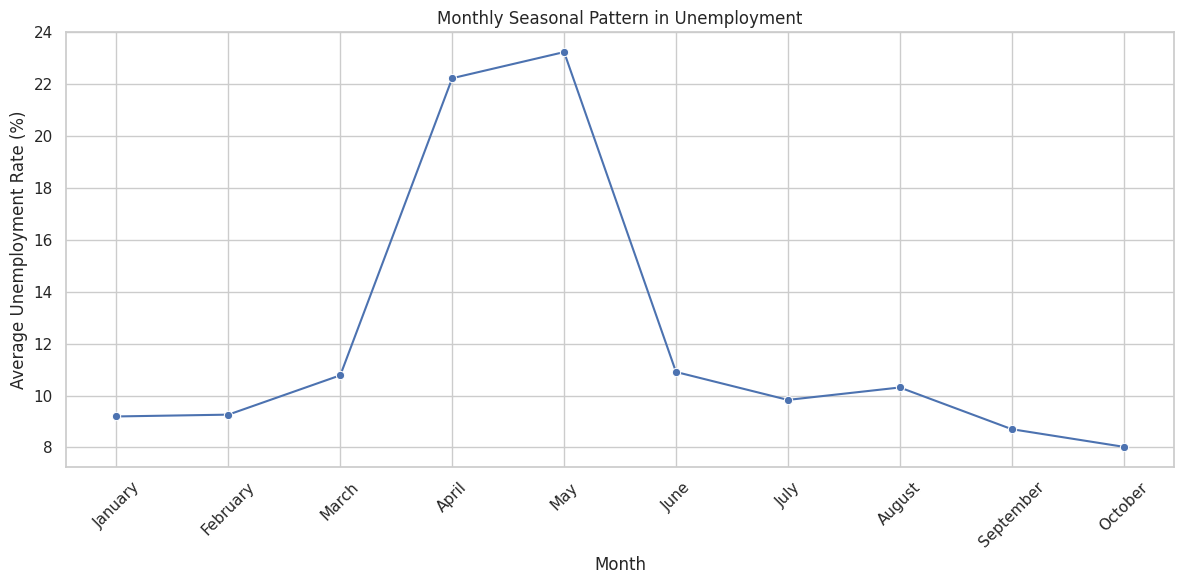

In [38]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_pattern,
    x="Month Name",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Monthly Seasonal Pattern in Unemployment")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 13. Unemployment and Labour Participation

This section investigates the relationship between unemployment
rate and labour participation rate.

In [39]:
correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

correlation

,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.00000,-0.07354
Estimated Labour Participation Rate (%),-0.07354,1.00000


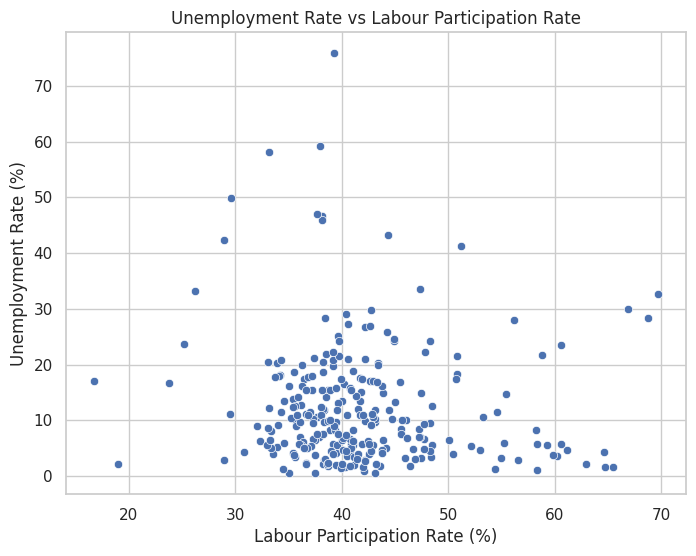

In [40]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Estimated Labour Participation Rate (%)",
    y="Estimated Unemployment Rate (%)"
)

plt.title(
    "Unemployment Rate vs Labour Participation Rate"
)

plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")

plt.show()

# 14. Key Findings

Based on the analysis, the following findings are identified:

1. Unemployment rates vary significantly across different regions.
2. The unemployment rate changed considerably during the COVID-19
   pandemic.
3. Some regions experienced considerably higher unemployment than
   others.
4. Rural and urban areas can show different unemployment patterns.
5. Monthly analysis can reveal possible seasonal variations.
6. The relationship between unemployment and labour participation
   provides additional insight into labour-market conditions.

The numerical values presented in the analysis are calculated directly
from the dataset.

# 15. Policy Insights

The analysis can provide several insights for economic and social
policy planning:

- Employment-support programs can be targeted toward regions with
  persistently high unemployment.
- During economic crises, governments can introduce temporary
  employment and income-support programs.
- Skill-development and reskilling programs can help improve
  employability.
- Rural and urban employment strategies should consider their
  different labour-market conditions.
- Regular monitoring of unemployment indicators can help identify
  emerging employment problems earlier.
- Seasonal unemployment patterns can be considered when planning
  employment programs.

# 16. Conclusion

This project analyzed unemployment data using Python and explored
changes in unemployment rates across time, regions, and different
periods.

The analysis demonstrates the impact of the COVID-19 pandemic on
unemployment and identifies regional and seasonal patterns.

Data visualization and exploratory analysis provide a clearer
understanding of unemployment trends and can support data-driven
economic and social policy decisions.

Overall, this project demonstrates the practical application of
Python, Pandas, NumPy, Matplotlib, and Seaborn for real-world
data analysis.